In [4]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/ids-intrusion-csv/02-28-2018.csv
/kaggle/input/ids-intrusion-csv/03-01-2018.csv
/kaggle/input/ids-intrusion-csv/02-16-2018.csv
/kaggle/input/ids-intrusion-csv/02-15-2018.csv
/kaggle/input/ids-intrusion-csv/02-21-2018.csv
/kaggle/input/ids-intrusion-csv/03-02-2018.csv
/kaggle/input/ids-intrusion-csv/02-22-2018.csv
/kaggle/input/ids-intrusion-csv/02-20-2018.csv
/kaggle/input/ids-intrusion-csv/02-14-2018.csv
/kaggle/input/ids-intrusion-csv/02-23-2018.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam
import gc
import warnings
warnings.filterwarnings('ignore')

# Kiểm tra GPU
print("GPU Available: ", tf.config.list_physical_devices('GPU'))

# 2. Tải dữ liệu (lấy mẫu 30% để chạy nhanh)
file_paths = [
    '/kaggle/input/ids-intrusion-csv/02-14-2018.csv',
    '/kaggle/input/ids-intrusion-csv/02-15-2018.csv',
    '/kaggle/input/ids-intrusion-csv/02-16-2018.csv',
    '/kaggle/input/ids-intrusion-csv/02-21-2018.csv',
    '/kaggle/input/ids-intrusion-csv/02-22-2018.csv',
    '/kaggle/input/ids-intrusion-csv/02-23-2018.csv',
    '/kaggle/input/ids-intrusion-csv/02-28-2018.csv',
    '/kaggle/input/ids-intrusion-csv/03-01-2018.csv',
    '/kaggle/input/ids-intrusion-csv/03-02-2018.csv'
]

def load_sampled_data(paths, frac=0.7):
    dfs = []
    for p in paths:
        print(f"Loading {p.split('/')[-1]}...")
        df = pd.read_csv(p, low_memory=False)
        df = df.sample(frac=frac, random_state=42)
        dfs.append(df)
        del df
        gc.collect()
    return pd.concat(dfs, ignore_index=True)

df = load_sampled_data(file_paths, frac=0.7)
print(f"Total samples: {len(df):,}")

GPU Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Loading 02-14-2018.csv...
Loading 02-15-2018.csv...
Loading 02-16-2018.csv...
Loading 02-21-2018.csv...
Loading 02-22-2018.csv...
Loading 02-23-2018.csv...
Loading 02-28-2018.csv...
Loading 03-01-2018.csv...
Loading 03-02-2018.csv...
Total samples: 5,798,974


In [6]:
drop_cols = ['Flow ID', 'Timestamp', 'Src IP', 'Dst IP']
existing_drop = [col for col in drop_cols if col in df.columns]
if existing_drop:
    df = df.drop(columns=existing_drop)
print(f"Removed {len(existing_drop)} Column: {existing_drop}")
print(f"\Initial Data Types:\n{df.dtypes.value_counts()}")
numeric_cols = [col for col in df.columns if col not in ['Label']]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print(f"\nNumber of numerical features after preprocessing: {len(numeric_cols)}")
print(f"Total samples: {len(df)}")
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])
print(f"Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")
X = df[numeric_cols].copy()
y = df['Label_encoded'].values
if X.empty or X.shape[1] == 0:
    raise ValueError("X Empty!")
print(f"X shape: {X.shape} (samples, features)")
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

Removed 1 Column: ['Timestamp']
\Initial Data Types:
object    79
Name: count, dtype: int64

Number of numerical features after preprocessing: 78
Total samples: 5798974
Classes: {'Benign': np.int64(0), 'Bot': np.int64(1), 'Brute Force -Web': np.int64(2), 'Brute Force -XSS': np.int64(3), 'DDOS attack-HOIC': np.int64(4), 'DDOS attack-LOIC-UDP': np.int64(5), 'DoS attacks-GoldenEye': np.int64(6), 'DoS attacks-Hulk': np.int64(7), 'DoS attacks-SlowHTTPTest': np.int64(8), 'DoS attacks-Slowloris': np.int64(9), 'FTP-BruteForce': np.int64(10), 'Infilteration': np.int64(11), 'Label': np.int64(12), 'SQL Injection': np.int64(13), 'SSH-Bruteforce': np.int64(14)}
X shape: (5798974, 78) (samples, features)


In [7]:
benign_mask = df['Label'] == 'Benign'
X_benign = X_scaled[benign_mask]
X_train_ae, X_val_ae = train_test_split(X_benign, test_size=0.2, random_state=42)
timesteps = 1
n_features = X_train_ae.shape[1]
X_train_ae = X_train_ae.reshape(-1, timesteps, n_features)
X_val_ae = X_val_ae.reshape(-1, timesteps, n_features)
print(f"Train AE: {X_train_ae.shape}, Val AE: {X_val_ae.shape}")

Train AE: (3423381, 1, 78), Val AE: (855846, 1, 78)


In [8]:
def build_autoencoder(timesteps, n_features, latent_dim=64):
    inputs = Input(shape=(timesteps, n_features))
    
    encoded = LSTM(128, return_sequences=False)(inputs)
    encoded = Dense(latent_dim, activation='relu')(encoded)
    
    decoded = RepeatVector(timesteps)(encoded)
    decoded = LSTM(128, return_sequences=True)(decoded)
    decoded = TimeDistributed(Dense(n_features))(decoded)
    
    autoencoder = Model(inputs, decoded)
    autoencoder.compile(optimizer=Adam(0.001), loss='mae')
    return autoencoder

autoencoder = build_autoencoder(timesteps, n_features, latent_dim=64)
autoencoder.summary()

I0000 00:00:1777385522.003512      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 78)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       105,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 1, 78)          │        10,062 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,118 (871.55 KB)

 Trainable params: 223,118 (871.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25


I0000 00:00:1777385571.322728     157 cuda_dnn.cc:529] Loaded cuDNN version 91002


13373/13373 ━━━━━━━━━━━━━━━━━━━━ 89s 6ms/step - loss: 0.0110 - val_loss: 0.0031
Epoch 2/25
13373/13373 ━━━━━━━━━━━━━━━━━━━━ 84s 6ms/step - loss: 0.0020 - val_loss: 9.8258e-04
Epoch 3/25
13373/13373 ━━━━━━━━━━━━━━━━━━━━ 84s 6ms/step - loss: 9.0055e-04 - val_loss: 8.0943e-04
Epoch 4/25
13373/13373 ━━━━━━━━━━━━━━━━━━━━ 88s 7ms/step - loss: 7.3509e-04 - val_loss: 6.5430e-04
Epoch 5/25
13373/13373 ━━━━━━━━━━━━━━━━━━━━ 88s 7ms/step - loss: 6.3844e-04 - val_loss: 6.3071e-04
Epoch 6/25
13373/13373 ━━━━━━━━━━━━━━━━━━━━ 88s 7ms/step - loss: 5.5955e-04 - val_loss: 5.2141e-04
Epoch 7/25
13373/13373 ━━━━━━━━━━━━━━━━━━━━ 88s 7ms/step - loss: 5.1522e-04 - val_loss: 5.2631e-04
Epoch 8/25
13373/13373 ━━━━━━━━━━━━━━━━━━━━ 84s 6ms/step - loss: 4.8452e-04 - val_loss: 4.7201e-04
Epoch 9/25
13373/13373 ━━━━━━━━━━━━━━━━━━━━ 84s 6ms/step - loss: 4.4894e-04 - val_loss: 4.5938e-04
Epoch 10/25
13373/13373 ━━━━━━━━━━━━━━━━━━━━ 85s 6ms/step - loss: 4.0871e-04 - val_loss: 4.2453e-04
Epoch 11/25
13373/13373 ━━━━━━━━

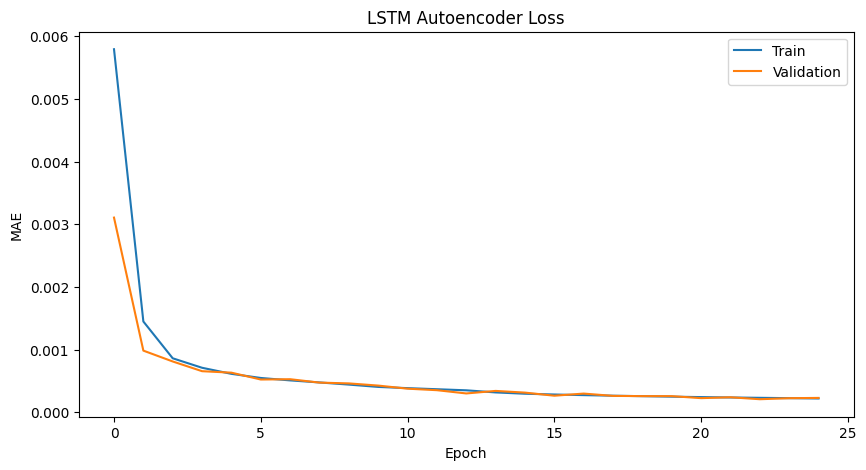

In [9]:
history = autoencoder.fit(
    X_train_ae, X_train_ae,
    epochs=25,
    batch_size=256,
    validation_data=(X_val_ae, X_val_ae),
    shuffle=True,
    verbose=1
)

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('LSTM Autoencoder Loss')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [10]:
X_all = X_scaled.reshape(-1, timesteps, n_features)
recon = autoencoder.predict(X_all, batch_size=256)
mse = np.mean(np.power(X_all - recon, 2), axis=(1,2))

val_idx = np.where(benign_mask)[0][-len(X_val_ae):]
val_mse = mse[val_idx]
threshold = np.percentile(val_mse, 95)
print(f"Threshold (95th %): {threshold:.6f}")

y_pred = (mse > threshold).astype(int)
y_true = (y != le.transform(['Benign'])[0]).astype(int)

22653/22653 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step
Threshold (95th %): 0.000001



=== KẾT QUẢ PHÁT HIỆN TẤN CÔNG ===
Accuracy : 0.9297
Precision: 0.8945
Recall   : 0.8297
F1-Score : 0.8609
TPR (True Positive Rate) : 0.8297
FPR (False Positive Rate): 0.0348


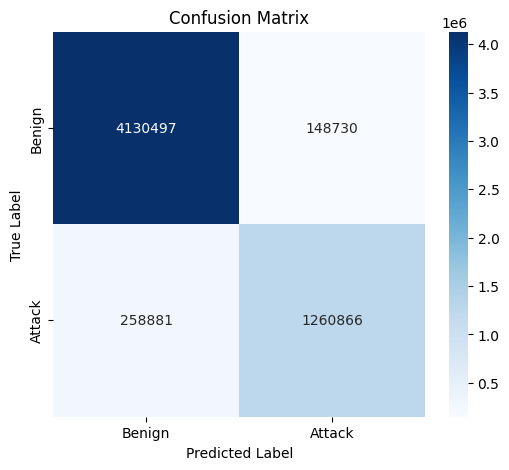

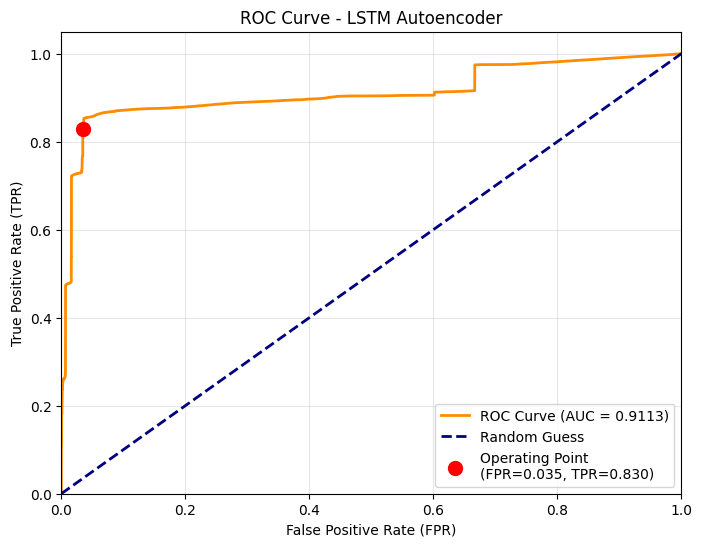

AUC Score: 0.9113


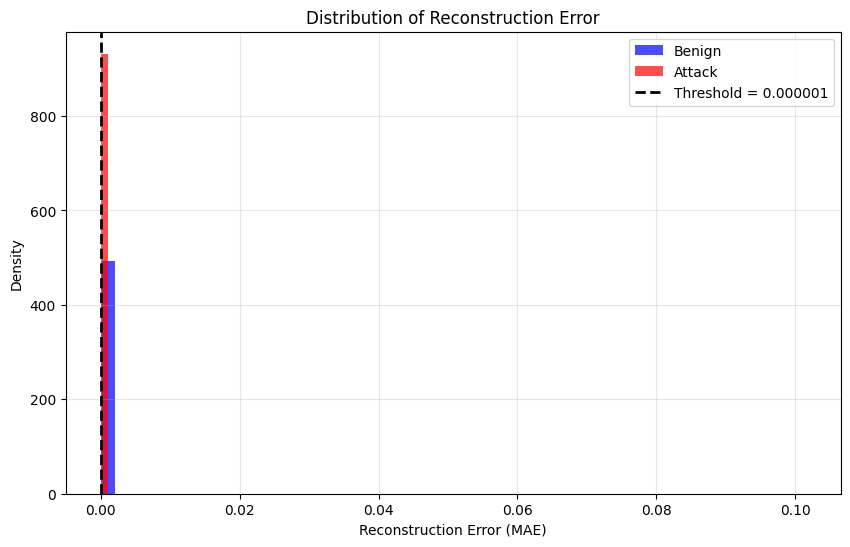

In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc)

print("\n=== KẾT QUẢ PHÁT HIỆN TẤN CÔNG ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_true, y_pred):.4f}")

# === TÍNH CONFUSION MATRIX ===
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# === TPR & FPR ===
tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"TPR (True Positive Rate) : {tpr:.4f}")
print(f"FPR (False Positive Rate): {fpr:.4f}")

# === VẼ CONFUSION MATRIX ===
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# =============================================
# 9. ROC CURVE & AUC
# =============================================

fpr_roc, tpr_roc, _ = roc_curve(y_true, mse)
roc_auc = auc(fpr_roc, tpr_roc)

plt.figure(figsize=(8,6))
plt.plot(fpr_roc, tpr_roc, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.scatter(fpr, tpr, color='red', s=100, 
            label=f'Operating Point\n(FPR={fpr:.3f}, TPR={tpr:.3f})', zorder=5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - LSTM Autoencoder')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

# =============================================
# 10. PHÂN PHỐI LỖI TÁI TẠO
# =============================================

plt.figure(figsize=(10,6))
plt.hist(mse[y_true == 0], bins=50, alpha=0.7, label='Benign', color='blue', density=True)
plt.hist(mse[y_true == 1], bins=50, alpha=0.7, label='Attack', color='red', density=True)
plt.axvline(threshold, color='black', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold:.6f}')
plt.xlabel('Reconstruction Error (MAE)')
plt.ylabel('Density')
plt.title('Distribution of Reconstruction Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

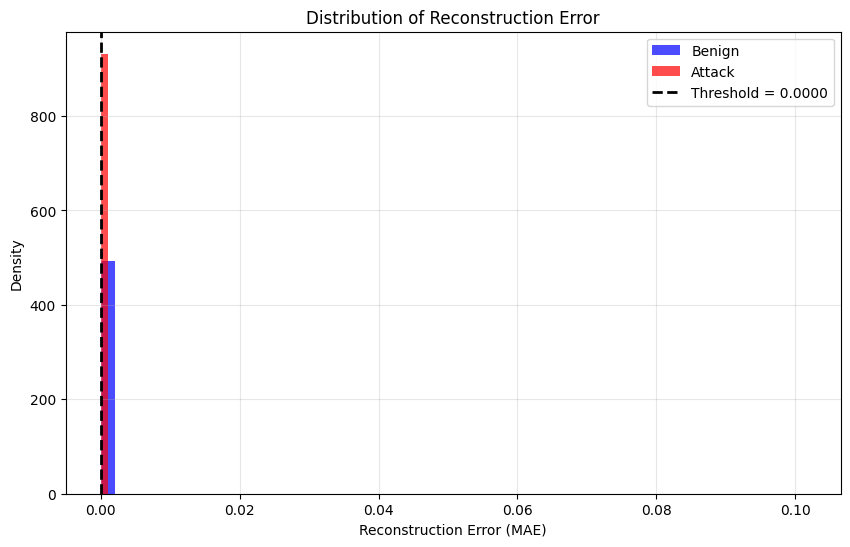

In [12]:
plt.figure(figsize=(10,6))
plt.hist(mse[y_true == 0], bins=50, alpha=0.7, label='Benign', color='blue', density=True)
plt.hist(mse[y_true == 1], bins=50, alpha=0.7, label='Attack', color='red', density=True)
plt.axvline(threshold, color='black', linestyle='--', linewidth=2, 
            label=f'Threshold = {threshold:.4f}')
plt.xlabel('Reconstruction Error (MAE)')
plt.ylabel('Density')
plt.title('Distribution of Reconstruction Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
import pickle
import numpy as np
import os
import zipfile
from google.colab import files
autoencoder.save('stm_full_model.keras')
autoencoder.save_weights('lstm_weights.weights.h5')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
np.save('threshold.npy', threshold)

In [15]:
import zipfile
import os
from IPython.display import FileLink

files_to_download = ['stm_full_model.keras', 'lstm_weights.weights.h5', 'scaler.pkl', 'threshold.npy']

with zipfile.ZipFile('model_package.zip', 'w') as zipf:
    for file in files_to_download:
        if os.path.exists(file):
            zipf.write(file)

FileLink(r'model_package.zip')

/kaggle/working/model_package.zip